In [32]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer


In [5]:
#with open("../data/ostatni_kanal.txt", "r", encoding="utf-8") as f:
 #   channel_name = f.read().strip()

channel_name = "KanalZero"
file_path = f"../data/processed/processed_{channel_name}_videos_info.csv"
channel_info= pd.read_csv(file_path)

duration_time = pd.to_timedelta(channel_info['duration'])
channel_info['duration_minutes'] = (duration_time.dt.total_seconds() /60).round(2)
print("Analiza kanału: ")
print(channel_name)

Analiza kanału: 
KanalZero


In [6]:
category_map = {
    "1": "Film & Animation",
    "2": "Autos & Vehicles",
    "10": "Music",
    "15": "Pets & Animals",
    "17": "Sports",
    "18": "Short Movies",
    "19": "Travel & Events",
    "20": "Gaming",
    "21": "Videoblogging",
    "22": "People & Blogs",
    "23": "Comedy",
    "24": "Entertainment",
    "25": "News & Politics",
    "26": "Howto & Style",
    "27": "Education",
    "28": "Science & Technology",
    "29": "Nonprofits & Activism",
    "30": "Movies",
    "31": "Anime/Animation",
    "32": "Action/Adventure",
    "33": "Classics",
    "34": "Comedy",
    "35": "Documentary",
    "36": "Drama",
    "37": "Family",
    "38": "Foreign",
    "39": "Horror",
    "40": "Sci-Fi/Fantasy",
    "41": "Thriller",
    "42": "Shorts",
    "43": "Shows",
    "44": "Trailers"
}

In [26]:
df_clean = channel_info.copy()

df_clean['category_id'] = df_clean['category_id'].astype(str).map(category_map).fillna("Inne")

df_clean['published_at'] = pd.to_datetime(df_clean['published_at']).dt.strftime('%Y-%m-%d')

df_final = df_clean[[
    'channel_name', 'title', 'published_at', 
    'view_count', 'like_count', 'comment_count', 
    'category_id', 'duration_minutes', 'clickbait_score', 'clickbait_level', 'engagement_rate_%'
]]

df_final.columns = [
    'Nazwa Kanału', 'Tytuł Filmu', 'Data Publikacji', 
    'Liczba Wyświetleń', 'Liczba Polubień', 'Liczba Komentarzy', 
    'Kategoria', 'Czas trwania (min)', 'Wynik Clickbait', 'Poziom Clickbait', 'Współczynnik Zaangażowania (%)'
]
df_final.head()

,Nazwa Kanału,Tytuł Filmu,Data Publikacji,Liczba Wyświetleń,Liczba Polubień,Liczba Komentarzy,Kategoria,Czas trwania (min),Wynik Clickbait,Poziom Clickbait,Współczynnik Zaangażowania (%)
11669,KanalZero,KANAŁ ZERO - CO TO BĘDZIE?,2023-11-14,1672992,135927,12272,People & Blogs,10.70,3,2. Lekki marketing newsowy,8.12
11668,KanalZero,TOMASZ RACZEK W KANALE ZERO! #kanalzero #racze...,2024-01-21,189948,6297,422,People & Blogs,0.97,2,1. Rzetelny / Neutralny,3.32
11667,KanalZero,TEDE W KANALE ZERO! #kanalzero #shorts #tede #...,2024-01-21,401826,7426,735,People & Blogs,0.85,2,1. Rzetelny / Neutralny,1.85
11666,KanalZero,MONIKA GOŹDZIALSKA W KANALE ZERO! #kanalzero #...,2024-01-22,208974,3625,497,People & Blogs,0.98,2,1. Rzetelny / Neutralny,1.73
11665,KanalZero,TOMASZ ROŻEK W KANALE ZERO! #kanalzero #shorts...,2024-01-22,169744,8505,338,People & Blogs,0.53,2,1. Rzetelny / Neutralny,5.01


## Analiza rozwoju kanału: Wyświetlenia, Polubienia, Komentarze, Długość trwania filmiku

Zestawienie trzech wykresów umożliwia sprawdzenie, czy wysoka liczba wyświetleń przekłada się proporcjonalnie na liczbę polubień i komentarzy. Jeśli piki na wykresie wyświetleń nie znajdują odzwierciedlenia w pozostałych kategoriach, może to sugerować materiały o charakterze czysto informacyjnym lub o niskiej zdolności do wywoływania dyskusji. W przeciwieństwie do skupisk punktów na wykresie komentarzy, które jasno pozwalają zidentyfikować tematy, które angażują widownię.

Text(0.5, 1.05, 'Analiza kanału: KanalZero')

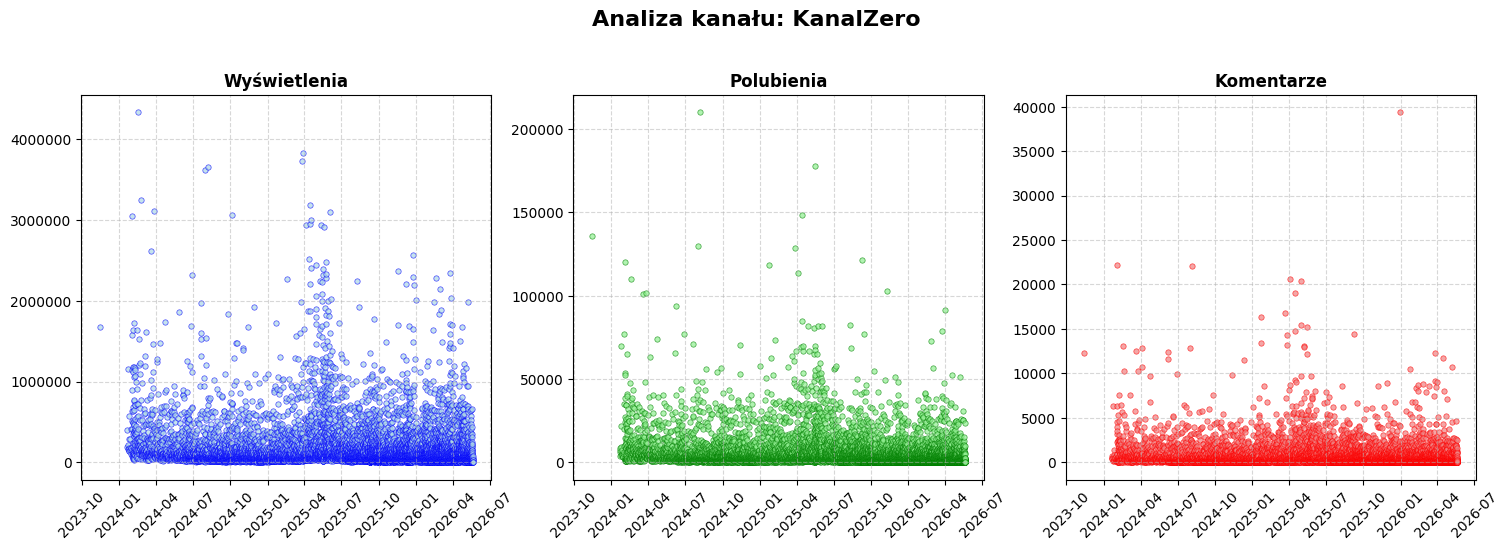

In [30]:

channel_info['published_at'] = pd.to_datetime(channel_info['published_at'])
channel_info = channel_info.sort_values('published_at')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metrics = [
    ('view_count', 'Wyświetlenia', 'lightblue', 'blue'),
    ('like_count', 'Polubienia', 'lightgreen', 'green'),
    ('comment_count', 'Komentarze', 'lightcoral', 'red')
]

for i, (col, title, color, edge) in enumerate(metrics):
    axes[i].scatter(channel_info['published_at'], channel_info[col], 
                    alpha=0.7, s=15, color=color, edgecolor=edge, linewidth=0.5)
    
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].ticklabel_format(style='plain', axis='y')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle(f'Analiza kanału: {channel_name}', fontsize=16, fontweight='bold', y=1.05)



## Histogram rozkładu długości filmów pozwalający ocenić strategię kanału

Rozkład gdzie występuje kilka szczytów Wskazuje na świadome zarządzanie różnymi formatami treści. Jeśli wykres posiada odrębne skupiska (np. jedno przy 5-10 minutach, a drugie przy 60+ minutach), oznacza to, że kanał równolegle rozwija szybkie formy wideo oraz długie wywiady. Jeśli histogram jest wyraźnie skupiony w jednym przedziale, kanał utrzymuje jeden, stały format produkcyjny.

Wykres punktowy uzupełnia tę analizę, pokazując chronologiczną ewolucję długości materiałów, co pozwala zweryfikować, czy twórca konsekwentnie trzyma się wypracowanego standardu, czy też w czasie eksperymentuje ze zmianą formatów wideo.

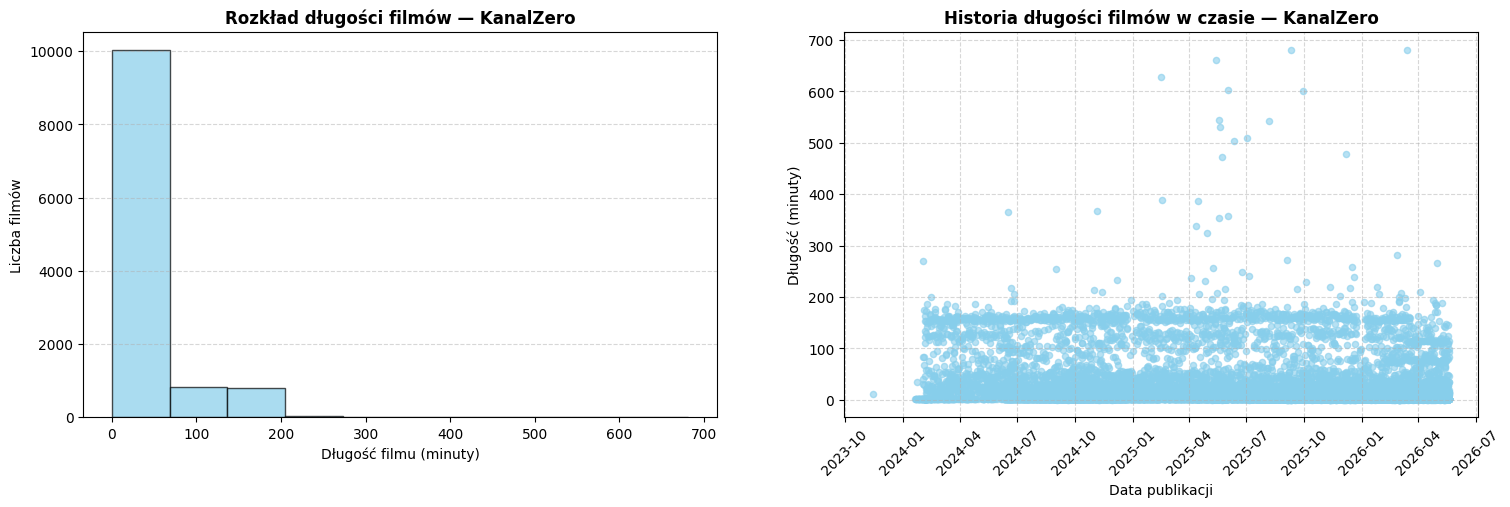

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.hist(channel_info['duration_minutes'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title(f'Rozkład długości filmów — {channel_name}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Długość filmu (minuty)', fontsize=10)
ax1.set_ylabel('Liczba filmów', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.scatter(channel_info['published_at'], channel_info['duration_minutes'], color='skyblue', marker='o', alpha=0.6, s=20)
ax2.set_title(f'Historia długości filmów w czasie — {channel_name}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Data publikacji', fontsize=10)
ax2.set_ylabel('Długość (minuty)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)

## Macierz współczynników korelacji Pearsona

Text(0.5, 1.0, 'Macierz korelacji cech: KanalZero')

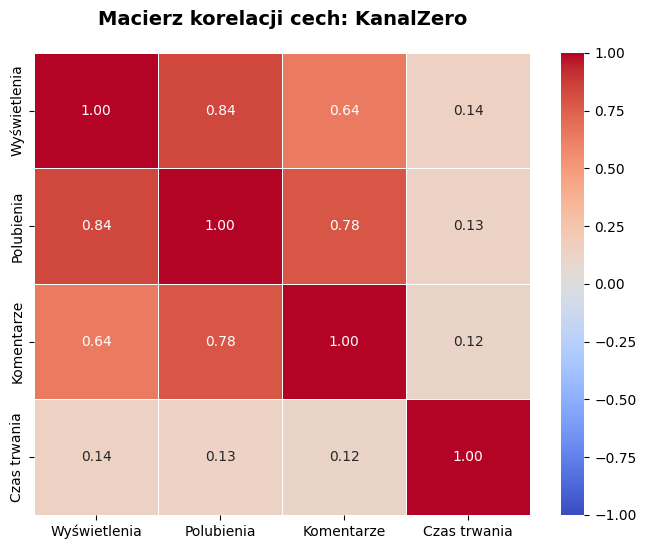

In [23]:

df_corr = channel_info[['view_count', 'like_count', 'comment_count', 'duration_minutes']].rename(columns={
    'view_count': 'Wyświetlenia',
    'like_count': 'Polubienia',
    'comment_count': 'Komentarze',
    'duration_minutes': 'Czas trwania'
})

korelacja = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelacja, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title(f'Macierz korelacji cech: {channel_name}', fontsize=14, fontweight='bold', pad=20)


## Statystyczne podsumowanie kluczowych metryk kanału
Prezentuje średnie wartości, zmienność zasięgów oraz charakterystykę długości publikowanych materiałów.

In [21]:

kolumny_analizy = ['duration_minutes', 'view_count', 'like_count', 'comment_count']

stats = channel_info[kolumny_analizy].describe().rename(columns={
    'duration_minutes': 'Czas trwania (min)',
    'view_count': 'Wyświetlenia',
    'like_count': 'Polubienia',
    'comment_count': 'Komentarze'
})

formatowanie = {
    'Wyświetlenia': '{:,.0f}',
    'Polubienia': '{:,.0f}',
    'Czas trwania (min)': '{:,.2f}',
    'Komentarze': '{:,.0f}'
}

stats.style.format(formatowanie).set_caption(f"Statystyki kanału: {channel_name}")

,Czas trwania (min),Wyświetlenia,Polubienia,Komentarze
count,"11,670.00","11,670","11,670","11,670"
mean,28.62,"162,034","4,723",560
std,50.57,"279,860","9,178","1,247"
min,0.10,"1,644",0,0
25%,1.02,"29,728",581,49
50%,8.27,"68,518","1,796",173
75%,26.58,"168,144","4,846",565
max,681.55,"4,338,756","210,302","39,387"


## Analiza clickbaitu

## Wykres regresji (Wpływ Clickbaitu na zasięg)

Wykres ten obrazuje relację między atrakcyjnością tytułu a liczbą wyświetleń, wskazując czy bardziej chwytliwe nagłówki realnie przekładają się na większy zasięg oraz sprawdza czy strategia obrana przez kanał jest skuteczna pod względem wyboru tytułu 

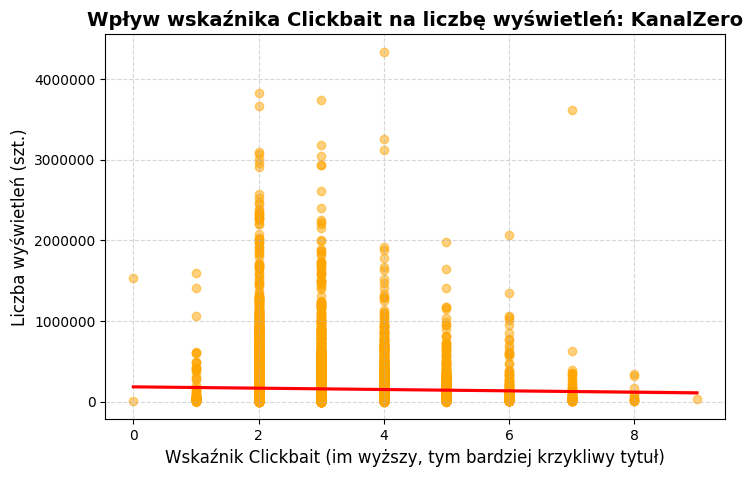

In [38]:

plt.figure(figsize=(8, 5))
sns.regplot(data=channel_info, x="clickbait_score", y="view_count", 
            scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'red'})
plt.title(f'Wpływ wskaźnika Clickbait na liczbę wyświetleń: {channel_name}', fontsize=14, fontweight='bold')
plt.xlabel('Wskaźnik Clickbait (im wyższy, tym bardziej krzykliwy tytuł)', fontsize=12)
plt.ylabel('Liczba wyświetleń (szt.)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')


## Wykres pudełkowy (Clickbait a zaangażowanie)

Zestawienie to prezentuje zależność między poziomem clickbaitu a rzeczywistym zaangażowaniem widzów, mierząc jakość interakcji po kliknięciu, sprawdza czy clickbaitowe tytuły zachęcają do dyskusji.

C:\Users\julka\AppData\Local\Temp\ipykernel_50548\523130208.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=channel_info, x="clickbait_score", y="engagement_rate_%", palette="coolwarm")


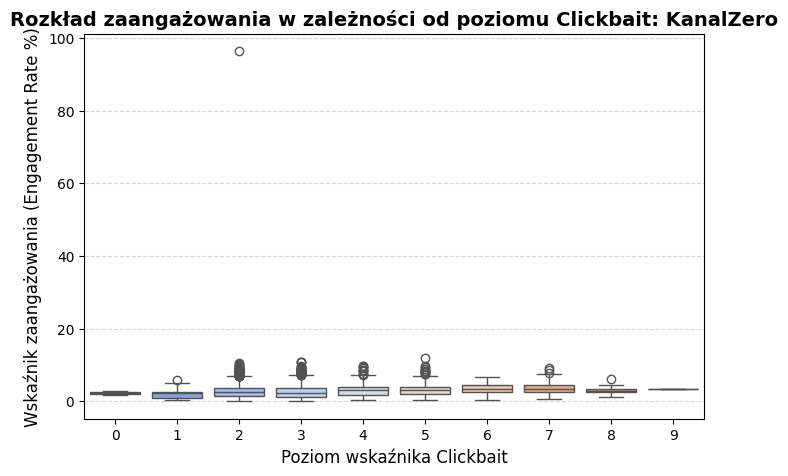

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=channel_info, x="clickbait_score", y="engagement_rate_%", palette="coolwarm")
plt.title(f'Rozkład zaangażowania w zależności od poziomu Clickbait: {channel_name}', fontsize=14, fontweight='bold')
plt.xlabel('Poziom wskaźnika Clickbait', fontsize=12)
plt.ylabel('Wskaźnik zaangażowania (Engagement Rate %)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)


## Tabela słów kluczowych (Analiza semantyczna)

Tabela przedstawia porównanie fraz najczęściej występujących w najpopularniejszych oraz najmniej docenianych filmach na kanale, pomaga zidentyfikować „język sukcesu” oraz eliminować zwroty, które statystycznie nie budzą zainteresowania widowni.

In [36]:
top = channel_info[channel_info["view_count"] >= channel_info["view_count"].quantile(0.8)]
bottom = channel_info[channel_info["view_count"] <= channel_info["view_count"].quantile(0.2)]

stopwords_pl = ["i", "a", "oraz", "że", "to", "na", "w", "z", "do", "od", "po", "jak", "czy", "się", "nie", "jest", "dla", "co", "o", "za"]

def get_ranking(df_subset):
    vec = TfidfVectorizer(ngram_range=(1, 2), stop_words=stopwords_pl)
    X = vec.fit_transform(df_subset["title"].astype(str))
    scores = X.sum(axis=0).A1
    return pd.DataFrame({"word": vec.get_feature_names_out(), "score": scores}).sort_values("score", ascending=False)

r_top, r_bot = get_ranking(top), get_ranking(bottom)
tabela = pd.DataFrame({
    'Lp.': range(1, 11),
    'Słowa (Top 20%)': r_top.head(10)['word'].values,
    'Wynik (Top)': r_top.head(10)['score'].round(2).values,
    'Słowa (Bottom 20%)': r_bot.head(10)['word'].values,
    'Wynik (Bottom)': r_bot.head(10)['score'].round(2).values
})
display(tabela.style.hide(axis='index'))

Lp.,Słowa (Top 20%),Wynik (Top),Słowa (Bottom 20%),Wynik (Bottom)
1,stanowski,56.270000,zero,25.120000
2,mazurek,44.740000,film,14.830000
3,zero,43.710000,nawrocki,14.660000
4,godzina zero,22.260000,polska,13.610000
5,godzina,22.260000,polski,12.180000
6,krzysztof,20.220000,kto,11.910000
7,nawrocki,19.330000,tusk,11.660000
8,krzysztof stanowski,18.170000,ma,11.540000
9,mazurek stanowski,16.880000,dlaczego,11.110000
10,robert,14.780000,polsce,10.880000
